# 03 · Ingesting a tower CSV

Real eddy-covariance processors (EddyPro, AmeriFlux) emit tabular output. Here we
load a tiny synthetic EddyPro-style file with `lagranged.io.read_ec_csv`, map its
columns onto `FootprintInputs`, convert a reported **variance** to a standard
deviation, filter on the quality-control flag, and run a single averaging period.

In [1]:
%matplotlib inline
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import lagranged as lg

warnings.filterwarnings("ignore", message="No measured TowerTurbulence")

## Locate and read the CSV

`read_ec_csv` renames source columns to `FootprintInputs` field names using a
mapping. The bundled `EDDYPRO_MAP` covers the common EddyPro "full output" names
(`u*`, `boundary_layer_height`, `v_var`, `wind_speed`, …).

In [2]:
# Resolve the sample CSV whether the notebook runs from examples/ or the repo root.
candidates = [
    Path("../tests/data/eddypro_sample.csv"),
    Path("tests/data/eddypro_sample.csv"),
]
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("eddypro_sample.csv not found next to the notebook")
print("Reading", csv_path)

df = lg.io.read_ec_csv(str(csv_path), mapping=lg.io.EDDYPRO_MAP)
df

Reading ..\tests\data\eddypro_sample.csv


,timestamp,zm,z0,d,ustar,wind_dir,h,L,sigma_v,umean,qc_flag
0,2023-07-15 10:00,3.0,0.03,0.2,0.34,205.0,950.0,-45.0,0.36,2.4,0
1,2023-07-15 10:30,3.0,0.03,0.2,0.31,212.0,1020.0,-120.0,0.33,2.1,0
2,2023-07-15 11:00,3.0,0.03,0.2,0.38,218.0,1180.0,-8000.0,0.40,2.8,1
3,2023-07-15 11:30,3.0,0.03,0.2,0.29,224.0,760.0,60.0,0.30,1.9,2
4,2023-07-15 12:00,3.0,0.03,0.2,0.42,231.0,1320.0,-30.0,0.45,3.1,0
5,2023-07-15 12:30,3.0,0.03,0.2,0.27,236.0,640.0,200.0,0.28,1.7,2


## Variance → standard deviation, then QC filter

EddyPro reports `v_var` (a **variance**), which the mapping renames to `sigma_v`.
The model wants the lateral velocity **standard deviation**, so take the square
root. We then drop records whose `qc_flag` marks them poor quality (the common
0 = best / 1 = ok / 2 = discard scheme).

In [3]:
# The 'sigma_v' column currently holds v_var (a variance) — convert to a std dev.
df["sigma_v"] = np.sqrt(df["sigma_v"])

good = df[df["qc_flag"] < 2].reset_index(drop=True)
print(f"{len(df)} records read, {len(good)} pass QC (qc_flag < 2)")
good[["timestamp", "L", "ustar", "wind_dir", "h", "sigma_v", "qc_flag"]]

6 records read, 4 pass QC (qc_flag < 2)


,timestamp,L,ustar,wind_dir,h,sigma_v,qc_flag
0,2023-07-15 10:00,-45.0,0.34,205.0,950.0,0.600000,0
1,2023-07-15 10:30,-120.0,0.31,212.0,1020.0,0.574456,0
2,2023-07-15 11:00,-8000.0,0.38,218.0,1180.0,0.632456,1
3,2023-07-15 12:00,-30.0,0.42,231.0,1320.0,0.670820,0


## Run one averaging period

In [4]:
row = good.iloc[0]
inputs = lg.FootprintInputs(
    zm=float(row.zm), z0=float(row.z0), d=float(row.d), L=float(row.L),
    ustar=float(row.ustar), umean=float(row.umean), wind_dir=float(row.wind_dir),
    h=float(row.h), sigma_v=float(row.sigma_v),
)
print(f"Period {row.timestamp}:  L={inputs.L:g} m, u*={inputs.ustar:g} m/s, "
      f"wind {inputs.wind_dir:g}°")

grid = lg.DomainGrid(nx=70, ny=70, dx=3.0, dy=3.0, x0=-80.0, y0=-105.0)
result = lg.FootprintModel(
    inputs, grid=grid,
    config=lg.ModelConfig(n_particles=700, dt_factor=0.05, t_max=110.0,
                          rebound_height=0.5, seed=11),
).run()
print(f"x_peak = {result.x_peak:.1f} m,  touchdowns = {result.n_touchdowns}")

Period 2023-07-15 10:00:  L=-45 m, u*=0.34 m/s, wind 205°


x_peak = 29.5 m,  touchdowns = 260


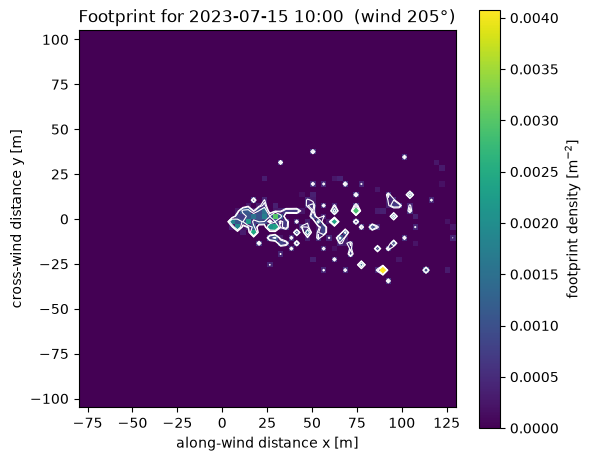

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
lg.plot_footprint(result, ax=ax)
lg.plot_contours(result, ax=ax, colors="white", linewidths=0.8)
ax.set_title(f"Footprint for {row.timestamp}  (wind {inputs.wind_dir:g}°)")
fig.tight_layout()
plt.show()

To process every good period instead of just the first, hand the QC-filtered frame
to `lagranged.run_batch` — that is the subject of
[`04_batch_geotiff_export`](04_batch_geotiff_export.ipynb).